# Example application

In [1]:
lat,lon = 48.149,11.507 # user residence
size = 50 # user travel area radius in km

In [2]:
!python --version
!pip install -r requirements.txt --disable-pip-version-check | tail -n 5

Python 3.12.8


In [3]:
import sys
import pandas as pd
import geopandas as gpd
import shapely as sh
import folium
from IPython.display import HTML,Image

In [4]:
data = pd.read_parquet('result-core-method/safeweb-DE.parquet')

data

,country,lat,lon,website,place_type
0,DE,51.0639209,13.7484667,www.madebyrons.de,Commerce
1,DE,50.4366168,7.569933,www.finea.de,Facility
2,DE,49.4981429,8.5545806,www.zahnarztpraxis-wallstadt.de,Facility
3,DE,48.0768836,11.5264376,www.d-bug.net,Commerce
4,DE,50.77299,7.3096747,www.friseur-hennef.de,Commerce
...,...,...,...,...,...
517612,DE,52.6597249,8.1201754,www.kolping-dinklage.de,Facility
517613,DE,51.8651214,8.9260597,www.teutoburgerwald.de,Facility
517614,DE,52.2582403,8.0892946,www.titgemeyer.de,Facility
517615,DE,48.9765434,12.1863489,www.eder-stapler.de,Unknown


In [5]:
data['crd'] = gpd.points_from_xy(data.lon,data.lat)
data = gpd.GeoDataFrame(data)
data.crd = data.crd.set_crs('EPSG:4326')

In [6]:
area = sh.Point(lon,lat)
area = gpd.GeoSeries(area).set_crs('EPSG:4326')
utm = area.estimate_utm_crs()
area = area.to_crs(utm)
area_whitelist = area.buffer(size*1000)
area_whitelist = area_whitelist.to_crs('EPSG:4326')
area_visual = area.buffer(3*1000)
area_visual = area_visual.to_crs('EPSG:4326')

In [7]:
data_whitelist = data.loc[data.crd.within(area_whitelist.item())]

data_whitelist

,country,lat,lon,website,place_type,crd
3,DE,48.0768836,11.5264376,www.d-bug.net,Commerce,POINT (11.52644 48.07688)
11,DE,47.9906819,11.8643731,glonn-feg.com,Facility,POINT (11.86437 47.99068)
26,DE,48.1910511,11.8677012,www.cms-carsharing.de,Facility,POINT (11.86770 48.19105)
95,DE,48.1037742,11.7691852,www.mvv-muenchen.de,Facility,POINT (11.76919 48.10377)
106,DE,47.9973091,11.171017,www.arthotel-herrsching.de,Facility,POINT (11.17102 47.99731)
...,...,...,...,...,...,...
517511,DE,48.098002,11.5233288,www.brunata-metrona.de,Facility,POINT (11.52333 48.09800)
517566,DE,48.1027366,11.5401548,www.terrafinanz.de,Unknown,POINT (11.54015 48.10274)
517582,DE,48.3052834,11.9044483,www.parisbarbershop.de,Commerce,POINT (11.90445 48.30528)
517587,DE,48.1731731,11.8066918,www.erzbistum-muenchen.de,Facility,POINT (11.80669 48.17317)


In [8]:
data_visual = data.loc[data.crd.within(area_visual.item())]

data_visual

,country,lat,lon,website,place_type,crd
329,DE,48.1384353,11.5027987,ruscher.de,Commerce,POINT (11.50280 48.13844)
439,DE,48.1532372,11.4783858,farnetani.de,Commerce,POINT (11.47839 48.15324)
1142,DE,48.1506159,11.5284681,www.sigo.green,Facility,POINT (11.52847 48.15062)
3618,DE,48.1514221,11.4771695,www.asb-muenchen.de,Facility,POINT (11.47717 48.15142)
3918,DE,48.1641784,11.4765688,www.rackls-backstubn.de,Commerce,POINT (11.47657 48.16418)
...,...,...,...,...,...,...
516494,DE,48.1479379,11.5163602,spielplatz-muenchen.de,Facility,POINT (11.51636 48.14794)
516744,DE,48.1435869,11.4837777,spielplatz-muenchen.de,Facility,POINT (11.48378 48.14359)
517060,DE,48.1354134,11.5366405,bergmann.musin.de,Facility,POINT (11.53664 48.13541)
517505,DE,48.1463586,11.5307398,www.naturheilkunde-rieder.de,Facility,POINT (11.53074 48.14636)


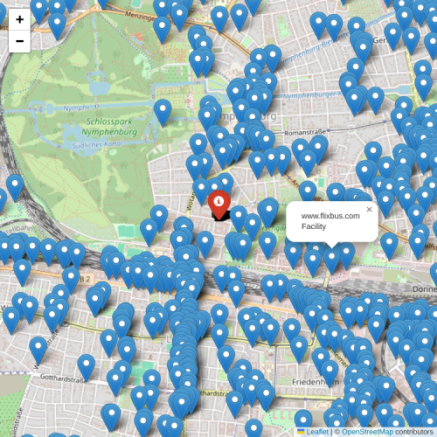

In [9]:
map_fl = folium.Map(zoom_start=14, location=[lat,lon],width=600, height=600)
folium.map.CustomPane('residence', z_index=1000).add_to(map_fl)

for item in data_visual.itertuples():
    
    folium.Marker(location=[item.lat,item.lon],
    popup=f'{item.website} {item.place_type}').add_to(map_fl)

    folium.Marker(location=[lat,lon],icon=folium.Icon(color='red'),
                  popup='User residence',pane='residence').add_to(map_fl)

map_fl.save(f'result-practical-use/example-visual-area.html')
    
#display(HTML(open(f'result-practical-use/example-visual-area.html').read()))
Image('result-practical-use/example-visual-area.png')

In [10]:
data_whitelist = data_whitelist.drop_duplicates(subset='website')

for item in ['Facility','Commerce','Combined']:
    
    print(item)
    if item == 'Combined':
        whitelist = data_whitelist.website
    else:
        whitelist = data_whitelist.loc[data_whitelist.place_type == item].website
    
    whitelist.to_csv(f'result-practical-use/example-area-whitelist-{item.lower()}.csv',index=False)
    print(f'Whitelist size {len(whitelist)}')
    print('Sample 100 records')
    print(whitelist.sample(100,random_state=0).tolist())
    #whitelist.sample(30,random_state=0).apply(lambda x: print(f'\\url{ {x} }',end=', ')) # manuscript format
    print()

Facility
Whitelist size 11480
Sample 100 records
['praxis-holley.de', 'fahrschule-aschmann.de', 'www.xaleris.com', 'www.paulaner.de', 'www.drlindner.de', 'www.ims-ambulance.de', 'www.fogra.org', 'www.makonis.de', 'ashoka-palace.de', 'www.physio-gemmeke.de', 'www.holledauer-rauten-gold.de', 'www.brunnen-apotheke-dah.de', 'www.milchhandwerk.info', 'www.bauspenglerei-manfred-huber.de', 'www.osteopathie-barbara-heckler.de', 'rwf-fos.de', 'bernhard-hof.de', 'www.internationales-kinderhaus.de', 'www.phamily.online', 'find.shell.com', 'gym-muc-moosach.musin.de', 'www.dinzler.de', 'www.wind-energie.de', 'www.lasaveur.de', 'www.naturkindergarten.org', 'derkleineflo.de', 'www.haflhof.de', 'heitschgalerie.de', 'www.comtecshop24.net', 'www.bricelta.de', 'www.diakonie-hasenbergl.de', 'www.baugenossenschaft-friedberg.de', 'www.bonaparthotel.de', 'www.tsv-schiltberg.de', 'kurzundklein.gmbh', 'zahnarzt-begemeier.de', 'www.mrwash.de', 'www.theaterviellaermumnichts.de', 'www.louis-hotel.com', 'saigondel